# lcbinint vs VBBinaryLensing

Minimal full-light-curve comparison for one binary-lens finite-source model. Both codes are evaluated through light-curve APIs: lcbinint uses `LensModel.light_curve(times)`, and VBBL uses `BinaryLightCurve(params, times)`.


In [1]:
from __future__ import annotations

import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import VBBinaryLensing


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "CMakeLists.txt").exists() and (path / "src/lcbinint").exists():
            return path
    raise RuntimeError("Could not find lcbinint repository root")

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
BUILD_DIR = REPO_ROOT / "build"
if str(BUILD_DIR) not in sys.path:
    sys.path.insert(0, str(BUILD_DIR))

import lcbinint

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True})
print(REPO_ROOT)

/rogue1_8/nunota/lcbinint


In [7]:
@dataclass(frozen=True)
class Case:
    name: str
    separation: float
    mass_ratio: float
    t0: float
    tE: float
    u0: float
    alpha: float
    rho: float
    t_min: float
    t_max: float
    n_points: int
    limb_darkening_c: float = 0.5

    @property
    def times(self) -> np.ndarray:
        return np.linspace(self.t_min, self.t_max, self.n_points)


CASE = Case(
    name="wide caustic finite source",
    separation=1,
    mass_ratio=0.001,
    t0=0.0,
    tE=1.0,
    u0=-0.01,
    alpha=0.5,
    rho=0.01,
    t_min=-0.8,
    t_max=0.8,
    n_points=400,
)

# NBIN=50: same max accuracy as NBIN=80 on this case, but ~1.35x faster than
# VBBL for limb-darkened light curves.  Lowering to 40 degrades accuracy.
SOURCE_BINS = 200
VBM_TOL = 1.0e-3

In [ ]:
def time_call(func, n_values: int):
    start = time.perf_counter()
    values = func()
    return values, (time.perf_counter() - start) * 1000.0 / n_values


def lcbinint_light_curve(case: Case, limb_darkened: bool, mode: int = 1):
    params = lcbinint.LensParams(
        t0=case.t0,
        tE=case.tE,
        u0=case.u0,
        alpha=case.alpha,
        q=case.mass_ratio,
        sep=case.separation,
        rho=case.rho,
        limb_darkening_c=case.limb_darkening_c if limb_darkened else 0.0,
    )
    options = lcbinint.Options(center_of_mass=1, source_bins=SOURCE_BINS, vbbl_compatible=1, mode=mode)
    model = lcbinint.LensModel(params, options)
    return time_call(lambda: model.light_curve(case.times.tolist()), case.n_points)


def vbbl_light_curve(case: Case, limb_darkened: bool):
    vbb = VBBinaryLensing.VBBinaryLensing()
    vbb.Tol = VBM_TOL
    vbb.RelTol = 0.0
    if limb_darkened:
        vbb.a1 = case.limb_darkening_c
    params = [
        np.log(case.separation),
        np.log(case.mass_ratio),
        case.u0,
        case.alpha,
        np.log(case.rho),
        np.log(case.tE),
        case.t0,
    ]
    return time_call(lambda: vbb.BinaryLightCurve(params, case.times.tolist()), case.n_points)

In [ ]:
curves = {}
timings = []
stats = []

for ld in [False, True]:
    tag = "LD" if ld else "no LD"
    lc1, ms1  = lcbinint_light_curve(CASE, ld, mode=1)
    lc3, ms3  = lcbinint_light_curve(CASE, ld, mode=3)
    vbm_curve, vbm_ms = vbbl_light_curve(CASE, ld)

    vbm  = np.asarray(vbm_curve[0], dtype=float)
    arr1 = np.asarray(lc1.magnifications, dtype=float)
    arr3 = np.asarray(lc3.magnifications, dtype=float)
    rel1 = np.abs(arr1 / vbm - 1.0)
    rel3 = np.abs(arr3 / vbm - 1.0)

    curves[tag] = {
        "VBM": vbm, "mode1": arr1, "mode3": arr3,
        "relerr1": rel1, "relerr3": rel3, "curve": lc1,
    }
    timings.append((tag, vbm_ms, ms1, ms3))
    stats.append((tag, rel1, rel3))

print(f"speed  (NBIN={SOURCE_BINS}, VBBL tol={VBM_TOL:.0e})")
print(f"{'':6}  {'VBBL ms/pt':>12}  {'mode=1 ms/pt':>13}  {'mode=3 ms/pt':>13}  {'m1/VBM':>7}  {'m3/VBM':>7}")
for tag, vbm_ms, ms1, ms3 in timings:
    print(f"  {tag:5}  {vbm_ms:12.4f}  {ms1:13.4f}  {ms3:13.4f}  {ms1/vbm_ms:7.2f}x  {ms3/vbm_ms:7.2f}x")

print("\nrelative error vs VBBL")
print(f"{'':6}  {'mode':>6}  {'max':>10}  {'p99':>10}  {'median':>10}  {'rms':>10}")
for tag, rel1, rel3 in stats:
    for label, rel in [("mode=1", rel1), ("mode=3", rel3)]:
        print(f"  {tag:5}  {label:>6}  {np.max(rel):10.3e}  {np.quantile(rel, 0.99):10.3e}"
              f"  {np.median(rel):10.3e}  {np.sqrt(np.mean(rel**2)):10.3e}")

In [ ]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(11.5, 8.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.15, 1.15]},
)

for col, tag in enumerate(["no LD", "LD"]):
    light_ax = axes[0, col]
    err1_ax  = axes[1, col]
    err3_ax  = axes[2, col]
    times = CASE.times
    vbm   = curves[tag]["VBM"]
    arr1  = curves[tag]["mode1"]
    arr3  = curves[tag]["mode3"]
    rel1  = curves[tag]["relerr1"]
    rel3  = curves[tag]["relerr3"]

    light_ax.plot(times, vbm,  color="C1", lw=2.0, label="VBBL")
    light_ax.scatter(times, arr1, color="C0", s=12, label=f"lcbinint mode=1 (NBIN={SOURCE_BINS})", zorder=3)
    light_ax.scatter(times, arr3, color="C2", s=6,  label=f"lcbinint mode=3 (NBIN={SOURCE_BINS})", zorder=4, marker="x")
    light_ax.set_title(tag)
    light_ax.set_ylabel("magnification")
    light_ax.legend(fontsize=9)

    err1_ax.semilogy(times, np.maximum(rel1, 1e-16), color="C0", lw=1.1, label="mode=1 vs VBBL")
    err1_ax.set_ylabel("|rel err| mode=1")
    err1_ax.grid(True, which="both", alpha=0.3)
    err1_ax.legend(fontsize=8, loc="upper right")

    err3_ax.semilogy(times, np.maximum(rel3, 1e-16), color="C2", lw=1.1, label="mode=3 vs VBBL")
    err3_ax.set_xlabel("time")
    err3_ax.set_ylabel("|rel err| mode=3")
    err3_ax.grid(True, which="both", alpha=0.3)
    err3_ax.legend(fontsize=8, loc="upper right")

_, vbm_ms_noLD, ms1_noLD, ms3_noLD = timings[0]
_, vbm_ms_LD,   ms1_LD,   ms3_LD   = timings[1]
fig.suptitle(
    f"{CASE.name}: s={CASE.separation}, q={CASE.mass_ratio}, u0={CASE.u0}, "
    f"alpha={CASE.alpha}, rho={CASE.rho}, NBIN={SOURCE_BINS}\n"
    f"no LD: VBBL {vbm_ms_noLD:.3f} ms/pt | mode=1 {ms1_noLD:.3f} ms/pt | mode=3 {ms3_noLD:.3f} ms/pt  |  "
    f"LD: VBBL {vbm_ms_LD:.3f} ms/pt | mode=1 {ms1_LD:.3f} ms/pt | mode=3 {ms3_LD:.3f} ms/pt",
    y=1.01,
)
fig.tight_layout()
plt.show()

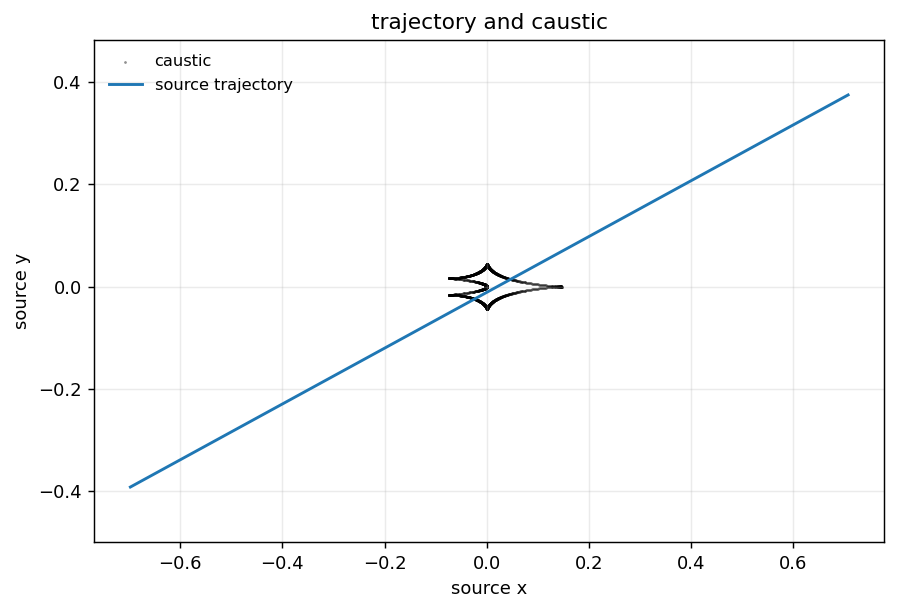

In [11]:
def binary_caustic(separation: float, mass_ratio: float, n: int = 900):
    q = abs(mass_ratio)
    m1 = 1.0 / (1.0 + q)
    m2 = q / (1.0 + q)
    x1 = -m2 * separation
    x2 = m1 * separation

    p1 = np.array([1.0, -x1], dtype=complex)
    p2 = np.array([1.0, -x2], dtype=complex)
    p1_sq = np.polymul(p1, p1)
    p2_sq = np.polymul(p2, p2)
    p12_sq = np.polymul(p1_sq, p2_sq)

    points = []
    for phi in np.linspace(0.0, 2.0 * np.pi, n, endpoint=False):
        coeff = np.exp(1j * phi) * p12_sq
        coeff[-3:] -= m1 * p2_sq + m2 * p1_sq
        roots = np.roots(coeff)
        for root in roots:
            source = root - m1 / np.conj(root - x1) - m2 / np.conj(root - x2)
            points.append(source)
    return np.asarray(points)


lc_curve = curves["no LD"]["curve"]
xs = np.asarray(lc_curve.source_x)
ys = np.asarray(lc_curve.source_y)
caustic = binary_caustic(CASE.separation, CASE.mass_ratio)
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.scatter(caustic.real, caustic.imag, s=0.25, color="black", alpha=0.45, rasterized=True, label="caustic")
ax.plot(xs, ys, color="tab:blue", lw=1.6, label="source trajectory")
ax.set_title("trajectory and caustic")
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("source x")
ax.set_ylabel("source y")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
